# Steam 리뷰 긍/부정 워드클라우드 파이프라인

**진행 순서**
1. **E**xtract(크롤러 호출) - **T**ransform - **L**oad (ETL)
2. 데이터 로드
3. 데이터 전처리
4. 긍정/부정 워드클라우드 시각화 (연어(collocation) 처리 포함)

- Extract: `crawler.py`의 `SteamReviewCrawler`로 Steam 리뷰 페이지를 크롤링 (Playwright 필요)
- 저장소: SQLite `meccha.db`


## 0. 라이브러리 준비

In [16]:
# 최초 1회 실행 (crawler.py가 필요로 하는 패키지들)
# !pip install playwright beautifulsoup4 lxml wordcloud --quiet
# !playwright install chromium
%pip install playwright beautifulsoup4 lxml wordcloud --quiet


Note: you may need to restart the kernel to use updated packages.


In [17]:
import sys, os
import json
import re
import sqlite3
from collections import Counter
from multiprocessing import Process

import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS

# 클로러 함수 import
CRAWLER_DIR = os.path.abspath(os.path.join("..", "crawler"))
sys.path.append(CRAWLER_DIR)
from crawler import run_crawler, setup_logger



In [18]:
pd.set_option('display.max_colwidth', 100)

# 공통 설정값
APP_ID = 4704690
OUTPUT_DIR = os.path.abspath(os.path.join("..", "data"))   # 크롤링 결과 JSON 저장/조회 위치
DB_PATH = os.path.join(OUTPUT_DIR, "meccha.db")             # OUTPUT_DIR 기준으로 파생
TABLE_NAME = "reviews"
KEEP_COLS = ["review_id", "sentiment", "review_text", "helpful_count"]

os.makedirs(OUTPUT_DIR, exist_ok=True)  # data 폴더가 없으면 생성

# 실제로 어디를 가리키는지 확인 (경로 문제 디버깅용)
print("CRAWLER_DIR:", CRAWLER_DIR)
print("OUTPUT_DIR :", OUTPUT_DIR)
print("DB_PATH    :", DB_PATH)


CRAWLER_DIR: /Users/admin/Documents/GitHub/softeer-w1-t3/missions/w2/crawler
OUTPUT_DIR : /Users/admin/Documents/GitHub/softeer-w1-t3/missions/w2/data
DB_PATH    : /Users/admin/Documents/GitHub/softeer-w1-t3/missions/w2/data/meccha.db


## 1. ETL

### Extract
스팀 게임 리뷰를 긍정/부정 나눠서 인터넷에서 크롤링합니다.

In [19]:
def extract(app_id: int, output_dir: str, target_reviews: int = 2000, force_recrawl: bool = False) -> list:
    os.makedirs(output_dir, exist_ok=True)
    positive_path = os.path.join(output_dir, "output_positive.json")
    negative_path = os.path.join(output_dir, "output_negative.json")

    already_crawled = os.path.exists(positive_path) and os.path.exists(negative_path)

    if force_recrawl or not already_crawled:
        print("[Extract] 크롤링을 시작합니다 (Playwright + 네트워크 필요)...")
        setup_logger()

        p_positive = Process(target=run_crawler, args=(app_id, "positive", positive_path, target_reviews))
        p_negative = Process(target=run_crawler, args=(app_id, "negative", negative_path, target_reviews))
        p_positive.start()
        p_negative.start()
        p_positive.join()
        p_negative.join()

        print("[Extract] 크롤링 완료")
    else:
        print("[Extract] 기존 크롤링 결과 파일을 사용합니다 (재크롤링 생략)")

    raw_data = []
    for path in (positive_path, negative_path):
        with open(path, "r", encoding="utf-8") as f:
            raw_data.extend(json.load(f))

    print(f"[Extract] 총 {len(raw_data)}건 로드")
    return raw_data


### Transform
크롤링한 데이터를 필요한 컬럼만 골라서 정제합니다.

In [20]:
def transform(raw_data: list, keep_cols: list) -> pd.DataFrame:
    df_raw = pd.DataFrame(raw_data)
    df = df_raw[keep_cols].copy()
    print(f"[Transform] 변환 후 shape: {df.shape}")
    return df


### Load
transform한 데이터를 데이터베이스 파일에 저장합니다.

In [21]:
def load(df: pd.DataFrame, db_path: str, table_name: str) -> None:
    """Load: DataFrame을 SQLite DB에 저장"""
    conn = sqlite3.connect(db_path)
    try:
        df.to_sql(table_name, conn, if_exists="replace", index=False)
        conn.commit()
    finally:
        conn.close()
    print(f"[Load] '{db_path}' 에 '{table_name}' 테이블로 {len(df)}건 저장 완료")


In [22]:
def run_etl(app_id: int, output_dir: str, db_path: str, table_name: str, keep_cols: list,
            target_reviews: int = 2000, force_recrawl: bool = False) -> pd.DataFrame:
    raw_data = extract(app_id, output_dir, target_reviews=target_reviews, force_recrawl=force_recrawl)
    df = transform(raw_data, keep_cols)
    load(df, db_path, table_name)
    return df


df_etl = run_etl(APP_ID, OUTPUT_DIR, DB_PATH, TABLE_NAME, KEEP_COLS, force_recrawl=False)
df_etl.head()


[Extract] 크롤링을 시작합니다 (Playwright + 네트워크 필요)...


2026-07-09 18:37:56,568 - INFO - [POSITIVE] Starting crawler...
2026-07-09 18:37:56,568 - INFO - [NEGATIVE] Starting crawler...
2026-07-09 18:37:56,568 - INFO - [NEGATIVE] Opening browser to URL: https://steamcommunity.com/app/4704690/negativereviews/?browsefilter=toprated&filterLanguage=english
2026-07-09 18:37:56,568 - INFO - [POSITIVE] Opening browser to URL: https://steamcommunity.com/app/4704690/positivereviews/?browsefilter=toprated&filterLanguage=english
2026-07-09 18:38:13,563 - INFO - [NEGATIVE] Successfully crawled and saved 100 reviews so far.
2026-07-09 18:38:18,157 - INFO - [POSITIVE] Successfully crawled and saved 100 reviews so far.
2026-07-09 18:38:29,935 - INFO - [NEGATIVE] Successfully crawled and saved 200 reviews so far.
2026-07-09 18:38:34,910 - INFO - [POSITIVE] Successfully crawled and saved 200 reviews so far.
2026-07-09 18:38:46,722 - INFO - [NEGATIVE] Successfully crawled and saved 300 reviews so far.
2026-07-09 18:38:51,819 - INFO - [POSITIVE] Successfully cr

[Extract] 크롤링 완료
[Extract] 총 4000건 로드
[Transform] 변환 후 shape: (4000, 4)
[Load] '/Users/admin/Documents/GitHub/softeer-w1-t3/missions/w2/data/meccha.db' 에 'reviews' 테이블로 4000건 저장 완료


,review_id,sentiment,review_text,helpful_count
0,https://steamcommunity.com/profiles/76561198830268492/recommended/4704690/,Positive,This game is basically an art contest for the hider and an eye exam for the hunter.,2303
1,https://steamcommunity.com/id/cabalotpt/recommended/4704690/,Positive,1st - Congrats on having an original idea for a game. 2nd - I've been having a lot of fun with i...,3122
2,https://steamcommunity.com/profiles/76561198031356113/recommended/4704690/,Positive,People with art degrees finally have something to exel at. Great game.,795
3,https://steamcommunity.com/profiles/76561198811233852/recommended/4704690/,Positive,"What a fun game, devs have been relentless with the updates as well, have already improved so mu...",464
4,https://steamcommunity.com/id/jrxonfire/recommended/4704690/,Positive,Ultra fun. Couldn't ask more for this price. I'd pay even 10 EUR. Edit: I actually did pay 10 EU...,302


## 2. 데이터 로드

SQLite(`meccha.db`)에서 데이터를 다시 불러옵니다. 이후 단계는 이 함수로 불러온 DataFrame을 사용합니다.


In [23]:
def load_data_from_db(db_path: str, table_name: str) -> pd.DataFrame:
    conn = sqlite3.connect(db_path)
    try:
        schema = pd.read_sql(f"PRAGMA table_info({table_name})", conn)
        sentiment_counts = pd.read_sql(
            f"SELECT sentiment, COUNT(*) AS cnt FROM {table_name} GROUP BY sentiment", conn
        )
        df = pd.read_sql(f"SELECT * FROM {table_name}", conn)
    finally:
        conn.close()

    print(f"[Data Load] '{table_name}' 테이블 로드 완료 - shape: {df.shape}")
    print("[Data Load] 테이블 스키마")
    display(schema)
    print("[Data Load] sentiment 분포")
    display(sentiment_counts)

    return df


df_db = load_data_from_db(DB_PATH, TABLE_NAME)
df_db.sample(5, random_state=42)


[Data Load] 'reviews' 테이블 로드 완료 - shape: (4000, 4)
[Data Load] 테이블 스키마


,cid,name,type,notnull,dflt_value,pk
0,0,review_id,TEXT,0,None,0
1,1,sentiment,TEXT,0,None,0
2,2,review_text,TEXT,0,None,0
3,3,helpful_count,INTEGER,0,None,0


[Data Load] sentiment 분포


,sentiment,cnt
0,Negative,1998
1,Positive,2002


,review_id,sentiment,review_text,helpful_count
555,https://steamcommunity.com/profiles/76561199500481940/recommended/4704690/,Positive,yes game is fun,0
3491,https://steamcommunity.com/profiles/76561197971773899/recommended/4704690/,Negative,"I love the premise of this game but I can't recommend it, it's so poorly made both 1st and 3rd p...",0
527,https://steamcommunity.com/id/alexisdino/recommended/4704690/,Positive,Sentir-se invisível pode ser uma experiência dolorosa ou um convite à reflexão sobre como lidamo...,0
3925,https://steamcommunity.com/id/macipapa22/recommended/4704690/,Negative,Such random bugs... sometimes it's impossible to enjoy because you have to restart 700 times for...,0
2989,https://steamcommunity.com/profiles/76561198193322870/recommended/4704690/,Negative,"I was expecting a lot from this game based on the clips I saw on the internet. However, this gam...",7


## 3. 데이터 전처리

1. 결측/공백 리뷰 제거
2. 텍스트 정제 (소문자화, URL 제거, 특수문자 제거 - 단, 축약형 부정문(`don't`, `isn't` 등)을 살리기 위해 어퍼스트로피(`'`)는 유지)
3. 감성별 데이터 분리

In [24]:
# 결측치 및 빈 리뷰 제거
def remove_missing_reviews(df: pd.DataFrame) -> pd.DataFrame:
    df_clean = df.dropna(subset=["review_text", "sentiment"]).copy()
    df_clean["review_text"] = df_clean["review_text"].astype(str).str.strip()
    df_clean = df_clean[df_clean["review_text"] != ""]
    print(f"[전처리] 결측/빈 리뷰 제거: {len(df)}건 -> {len(df_clean)}건")
    return df_clean


def clean_text(text: str) -> str:
    text = text.lower()  # 소문자와
    text = re.sub(r"http\S+|www\.\S+", " ", text) # url 제거
    text = re.sub(r"[^a-z\s']", " ", text)   # 특수문자/숫자 제거. 부정 축약형 보존을 위해 ' 는 남김
    text = re.sub(r"\s+", " ", text).strip()
    return text


# 감성별로 DataFrame 분리
def split_by_sentiment(df: pd.DataFrame):
    df_positive = df[df["sentiment"].str.lower() == "positive"]
    df_negative = df[df["sentiment"].str.lower() == "negative"]
    print(f"[전처리] 긍정 리뷰: {len(df_positive)}건 / 부정 리뷰: {len(df_negative)}건")
    return df_positive, df_negative


# 전처리 파이프라인 전체 실행
def preprocess(df: pd.DataFrame):
    df_clean = remove_missing_reviews(df)
    df_clean["clean_text"] = df_clean["review_text"].apply(clean_text)
    df_positive, df_negative = split_by_sentiment(df_clean)
    return df_clean, df_positive, df_negative


df_clean, df_positive, df_negative = preprocess(df_db)
df_clean[["review_text", "clean_text"]].head()

[전처리] 결측/빈 리뷰 제거: 4000건 -> 3995건
[전처리] 긍정 리뷰: 1998건 / 부정 리뷰: 1997건


,review_text,clean_text
0,This game is basically an art contest for the hider and an eye exam for the hunter.,this game is basically an art contest for the hider and an eye exam for the hunter
1,1st - Congrats on having an original idea for a game. 2nd - I've been having a lot of fun with i...,st congrats on having an original idea for a game nd i've been having a lot of fun with it rd pl...
2,People with art degrees finally have something to exel at. Great game.,people with art degrees finally have something to exel at great game
3,"What a fun game, devs have been relentless with the updates as well, have already improved so mu...",what a fun game devs have been relentless with the updates as well have already improved so much...
4,Ultra fun. Couldn't ask more for this price. I'd pay even 10 EUR. Edit: I actually did pay 10 EU...,ultra fun couldn't ask more for this price i'd pay even eur edit i actually did pay eur bought a...


## 4. 워드클라우드 시각화 (연어(collocation) 처리 포함)

- `collocations=True`로 설정해서 원문 텍스트에서 자주 붙어 다니는 두 단어(bigram)를
  하나의 표현으로 묶음. `not fun`, `so much fun` 등의 문맥적 의미를 살리기 위함
- 이를 위해 부정어(`not`, `no`, `isn't` 등)는 불용어 목록에서 제외하지 않음


In [25]:
# WordCloud 기본 불용어 목록에서 부정어를 제외하고, 도메인 불용어를 추가
NEGATION_WORDS = {
    "no", "not", "nor", "never", "none", "nothing", "cannot",
    "can't", "don't", "doesn't", "didn't", "isn't", "wasn't", "aren't",
    "weren't", "won't", "wouldn't", "couldn't", "shouldn't",
    "hasn't", "haven't", "hadn't", "n't",
}

DOMAIN_STOPWORDS = {"game", "games", "play", "played", "playing"}

CUSTOM_STOPWORDS = (set(STOPWORDS) - NEGATION_WORDS) | DOMAIN_STOPWORDS


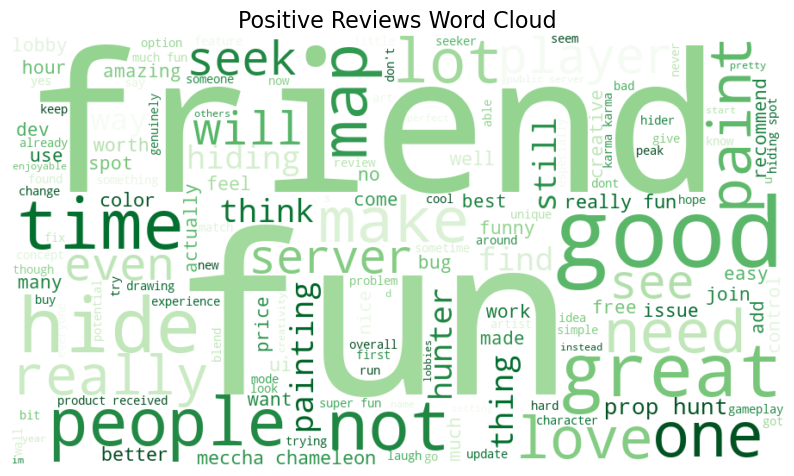

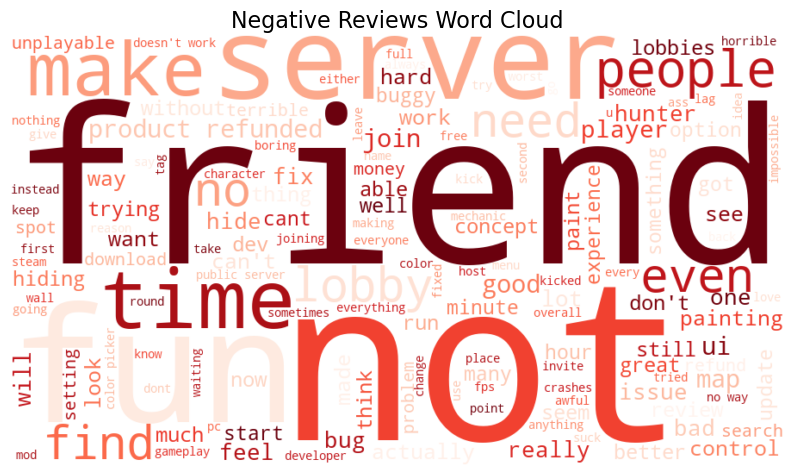

긍정 리뷰 상위 단어 TOP 10
  fun: 1.0
  friend: 0.733
  good: 0.545
  hide: 0.309
  great: 0.298
  time: 0.261
  not: 0.252
  people: 0.233
  map: 0.22
  make: 0.209
부정 리뷰 상위 단어 TOP 10
  not: 1.0
  friend: 0.923
  fun: 0.841
  server: 0.704
  time: 0.598
  make: 0.487
  people: 0.427
  lobby: 0.375
  no: 0.371
  even: 0.371


In [26]:
def build_wordcloud(text: str, title: str, colormap: str, stopwords: set) -> dict:
    wc = WordCloud(
        width=900,
        height=500,
        background_color="white",
        colormap=colormap,
        max_words=150,
        stopwords=stopwords,
        collocations=True,          # 연어(collocation) 처리
        collocation_threshold=10,   # 값이 작을수록 더 많은 두 단어 조합을 연어로 인정
    ).generate(text)

    plt.figure(figsize=(10, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title, fontsize=16)
    plt.show()

    return wc.words_


# 상위 빈도 단어 출력
def print_top_words(freq: dict, label: str, top_n: int = 10) -> None:
    print(f"{label} 상위 단어 TOP {top_n}")
    for word, cnt in Counter(freq).most_common(top_n):
        print(f"  {word}: {round(cnt, 3)}")


# 긍정/부정 클라우드를 한 번에 생성
def generate_sentiment_wordclouds(df_positive: pd.DataFrame, df_negative: pd.DataFrame, stopwords: set = CUSTOM_STOPWORDS):
    positive_text = " ".join(df_positive["clean_text"])
    negative_text = " ".join(df_negative["clean_text"])

    positive_freq = build_wordcloud(positive_text, "Positive Reviews Word Cloud", "Greens", stopwords)
    negative_freq = build_wordcloud(negative_text, "Negative Reviews Word Cloud", "Reds", stopwords)
    print_top_words(positive_freq, "긍정 리뷰")
    print_top_words(negative_freq, "부정 리뷰")

    return positive_freq, negative_freq


positive_freq, negative_freq = generate_sentiment_wordclouds(df_positive, df_negative)


## 5. 부정 리뷰 상위 키워드의 리뷰 등장률

- 부정 리뷰에서 등장 빈도가 높은 상위 키워드(`friend`, `server`, `time` 등)를 추출한다.
- 각 키워드가 **부정 리뷰 전체 중 몇 %의 리뷰에서 실제로 언급되는지**(document frequency)를 계산합니다.
  - 단/복수형 등 어형 변화(`friend`/`friends`)를 함께 잡기 위해 키워드 뒤에 알파벳이 더 붙는 경우도 포함한다.
- 하나의 리뷰에 여러 키워드가 동시에 등장 가능하다.

In [27]:
TOP_N_KEYWORDS = 8


def compute_keyword_review_share(df_negative: pd.DataFrame, freq: dict, top_n: int) -> pd.Series:
    """부정 리뷰 중 상위 키워드가 실제로 등장한 리뷰의 비율(%)을 계산"""
    total_reviews = len(df_negative)
    top_keywords = [word for word, _ in Counter(freq).most_common(top_n)]

    shares = {}
    for keyword in top_keywords:
        # 단어(공백 없음)는 어형 변화(friend/friends)까지 잡도록 뒤쪽을 느슨하게 매칭
        suffix = r"\b" if " " in keyword else r"[a-z]*\b"
        pattern = r"\b" + re.escape(keyword) + suffix
        contains = df_negative["clean_text"].str.contains(pattern, regex=True)
        shares[keyword] = contains.sum() / total_reviews * 100

    return pd.Series(shares, name="review_share_pct").sort_values(ascending=False)


keyword_share = compute_keyword_review_share(df_negative, negative_freq, TOP_N_KEYWORDS)
print(f"[부정 리뷰 {len(df_negative)}건 중 상위 키워드별 등장 비율]")
display(keyword_share.round(1))


[부정 리뷰 1997건 중 상위 키워드별 등장 비율]


not       28.7
fun       21.6
friend    20.9
server    17.0
time      14.7
make      10.3
people     9.4
lobby      8.9
Name: review_share_pct, dtype: float64

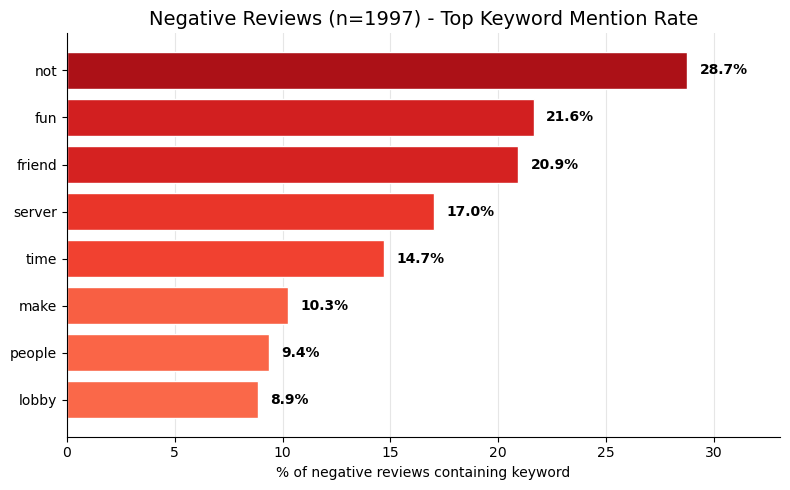

참고: 한 리뷰에 여러 키워드가 동시에 등장할 수 있어 각 막대의 비율은 서로 독립적으로 계산되었습니다.


In [28]:
def plot_keyword_bar(keyword_share: pd.Series, total_reviews: int) -> None:
    """키워드별 리뷰 등장 비율을 막대그래프로 시각화 (값이 클수록 진한 색)"""
    ordered = keyword_share.sort_values(ascending=True)  # barh는 아래->위로 그려지므로 오름차순 정렬

    norm = plt.Normalize(vmin=0, vmax=ordered.max())
    colors = plt.get_cmap("Reds")(0.35 + 0.5 * norm(ordered.values))

    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.barh(ordered.index, ordered.values, color=colors, edgecolor="white")

    for bar, value in zip(bars, ordered.values):
        ax.text(bar.get_width() + ordered.max() * 0.02, bar.get_y() + bar.get_height() / 2,
                f"{value:.1f}%", va="center", fontsize=10, fontweight="bold")

    ax.set_xlabel("% of negative reviews containing keyword")
    ax.set_xlim(0, ordered.max() * 1.15)
    ax.set_title(f"Negative Reviews (n={total_reviews}) - Top Keyword Mention Rate", fontsize=14)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="x", color="0.9", linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    plt.tight_layout()
    plt.show()

    print("참고: 한 리뷰에 여러 키워드가 동시에 등장할 수 있어 각 막대의 비율은 서로 독립적으로 계산되었습니다.")


plot_keyword_bar(keyword_share, len(df_negative))


## 6. 'friend'와 'server' 동시 등장 비율

- 두 키워드 `friend`, `server`에 대해
  - 함께 언급된 비율 (전체 부정 리뷰 대비)
  - 조건부 비율: 키워드 A가 등장한 리뷰들 중 키워드 B도 함께 등장한 비율, 그리고 그 반대

In [29]:
import itertools

KEYWORDS = ["friend", "server"]


def contains_keyword(df_negative: pd.DataFrame, keyword: str) -> pd.Series:
    pattern = r"\b" + re.escape(keyword) + r"[a-z]*\b"
    return df_negative["clean_text"].str.contains(pattern, regex=True)


def compute_pair_cooccurrence(df_negative: pd.DataFrame, keyword_a: str, keyword_b: str) -> dict:
    """두 키워드의 동시 등장 비율과, 한 키워드가 등장했을 때 다른 키워드도 등장할 조건부 비율을 계산"""
    total_reviews = len(df_negative)
    mask_a = contains_keyword(df_negative, keyword_a)
    mask_b = contains_keyword(df_negative, keyword_b)
    mask_both = mask_a & mask_b

    given_a_pct = mask_both.sum() / mask_a.sum() * 100 if mask_a.sum() else 0.0
    given_b_pct = mask_both.sum() / mask_b.sum() * 100 if mask_b.sum() else 0.0

    return {
        "keyword_a": keyword_a,
        "keyword_b": keyword_b,
        "both_pct": mask_both.sum() / total_reviews * 100,
        "a_given_b_pct": given_b_pct,
        "b_given_a_pct": given_a_pct,
    }


pair_results = [
    compute_pair_cooccurrence(df_negative, kw_a, kw_b)
    for kw_a, kw_b in itertools.combinations(KEYWORDS, 2)
]

for r in pair_results:
    print(f"[부정 리뷰 {len(df_negative)}건 기준] \'{r['keyword_a']}\' & \'{r['keyword_b']}\'")
    print(f"  함께 언급된 리뷰: {r['both_pct']:.1f}%")
    print(f"  \'{r['keyword_a']}\' 언급 리뷰 중 \'{r['keyword_b']}\'도 언급된 비율: {r['b_given_a_pct']:.1f}%")
    print(f"  \'{r['keyword_b']}\' 언급 리뷰 중 \'{r['keyword_a']}\'도 언급된 비율: {r['a_given_b_pct']:.1f}%")
    print()


[부정 리뷰 1997건 기준] 'friend' & 'server'
  함께 언급된 리뷰: 7.8%
  'friend' 언급 리뷰 중 'server'도 언급된 비율: 37.1%
  'server' 언급 리뷰 중 'friend'도 언급된 비율: 45.6%



In [30]:
# 결과를 표로 정리
pair_table = pd.DataFrame(pair_results)[
    ["keyword_a", "keyword_b", "both_pct", "b_given_a_pct", "a_given_b_pct"]
].rename(columns={
    "keyword_a": "키워드 A",
    "keyword_b": "키워드 B",
    "both_pct": "A & B 모두 언급 (전체 대비, %)",
    "b_given_a_pct": "A 언급 시 B도 언급 (%)",
    "a_given_b_pct": "B 언급 시 A도 언급 (%)",
})
pair_table = pair_table.round(1)
display(pair_table)


,키워드 A,키워드 B,"A & B 모두 언급 (전체 대비, %)",A 언급 시 B도 언급 (%),B 언급 시 A도 언급 (%)
0,friend,server,7.8,37.1,45.6
